<a href="https://colab.research.google.com/github/David4280/Computer-Science-12/blob/master/Colab_DataViz_Stats_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Data Visualization & Statistics Project (Real‑World Data)

This notebook uses **Our World in Data – CO₂ and Greenhouse Gas Emissions** (public dataset) to practice:
1. Loading & cleaning real‑world data
2. Descriptive statistics
3. Visualizations (histogram, boxplot, time series, scatter, heatmap)
4. Correlation analysis
5. Hypothesis testing (two‑sample t‑test)
6. Simple linear regression (with residual check)

**Dataset source:** Our World in Data – CO₂ dataset (CSV):
https://github.com/owid/co2-data (file: `owid-co2-data.csv`)

---
## How to use
- Run cells in order (top to bottom).
- Change `COUNTRIES` to yours of interest (e.g., `['Canada', 'United States', 'China']`).
- Toggle Drive saving with `USE_DRIVE`.


## 0) Setup
- Imports
- Optional: mount Google Drive to save outputs


In [ ]:
import sys, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

print("Python:", sys.version.split()[0], "Platform:", platform.platform())

# Plot style: keep defaults (good practice for tutorials)
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['axes.grid'] = True

USE_DRIVE = True  # set False if you don't want to mount Drive
OUTPUT_DIR = None
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True)
        OUTPUT_DIR = Path('/content/drive/MyDrive/Colab_Projects/dataviz_stats_outputs')
    except Exception as e:
        print("Colab not detected or Drive mount failed, saving locally.")
        OUTPUT_DIR = Path('/content/dataviz_stats_outputs')
else:
    OUTPUT_DIR = Path('/content/dataviz_stats_outputs')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

Python: 3.12.11 Platform: Linux-6.6.97+-x86_64-with-glibc2.35
Mounted at /content/drive


PosixPath('/content/drive/MyDrive/Colab_Projects/dataviz_stats_outputs')

## 1) Load dataset (OWID CO₂)
Columns of interest (subset): `country`, `year`, `co2`, `co2_per_capita`, `gdp`, `population`, `primary_energy_consumption`.


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(DATA_URL)
cols = ['country','iso_code','year','co2','co2_per_capita','gdp','population','primary_energy_consumption']
df = df[cols].copy()
df = df[df['iso_code'].str.len()==3]  # keep countries/territories (exclude aggregates like 'OWID_KOS')
df.head()

,country,iso_code,year,co2,co2_per_capita,gdp,population,primary_energy_consumption
0,Afghanistan,AFG,1750,NaN,NaN,NaN,2802560.0,NaN
1,Afghanistan,AFG,1751,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1752,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,1753,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,1754,NaN,NaN,NaN,NaN,NaN


## 2) Quick EDA
- Check shape, types, basic summary
- Look at missing values


In [ ]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing per column:\n", df.isna().sum())
df.describe(include='all')

Shape: (42262, 8)

Dtypes:
 country                        object
iso_code                       object
year                            int64
co2                           float64
co2_per_capita                float64
gdp                           float64
population                    float64
primary_energy_consumption    float64
dtype: object

Missing per column:
 country                           0
iso_code                          0
year                              0
co2                           19069
co2_per_capita                19491
gdp                           27032
population                     4046
primary_energy_consumption    32816
dtype: int64


,country,iso_code,year,co2,co2_per_capita,gdp,population,primary_energy_consumption
count,42262,42262,42262.000000,23193.000000,22771.000000,1.523000e+04,3.821600e+04,9446.000000
unique,218,218,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN
freq,274,274,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1922.746037,76.196703,3.946345,2.493125e+11,1.455663e+07,627.376854
std,NaN,NaN,63.308247,430.673768,15.350315,1.087111e+12,7.064053e+07,2601.331334
min,NaN,NaN,1750.000000,0.000000,0.000000,4.998000e+07,2.150000e+02,0.000000
25%,NaN,NaN,1878.000000,0.253000,0.172000,7.866681e+09,2.730268e+05,6.171500
50%,NaN,NaN,1927.000000,2.730000,1.002000,2.739213e+10,1.959932e+06,53.848500
75%,NaN,NaN,1975.000000,22.412000,4.299000,1.207120e+11,7.172267e+06,315.034000


## 3) Filter countries of interest & recent years
Change `COUNTRIES` to your preference. We'll focus on the 1990–2024 period (if available).


In [ ]:
COUNTRIES = ['Canada','United States','China','India']
YEAR_MIN, YEAR_MAX = 1990, 2024
dd = df[(df['country'].isin(COUNTRIES)) & (df['year'].between(YEAR_MIN, YEAR_MAX))].copy()
dd.sort_values(['country','year'], inplace=True)
dd.head()

,country,iso_code,year,co2,co2_per_capita,gdp,population,primary_energy_consumption
8802,Canada,CAN,1990,458.015,16.482,8.359968e+11,27789436.0,3008.582
8803,Canada,CAN,1991,449.756,15.973,8.202743e+11,28157153.0,3020.828
8804,Canada,CAN,1992,463.497,16.263,8.297421e+11,28500065.0,3101.725
8805,Canada,CAN,1993,464.160,16.100,8.537760e+11,28830635.0,3180.007
8806,Canada,CAN,1994,478.631,16.421,8.948519e+11,29147382.0,3301.156


## 4) Visualizations
All plots use **matplotlib**. Each figure is saved to `OUTPUT_DIR`.


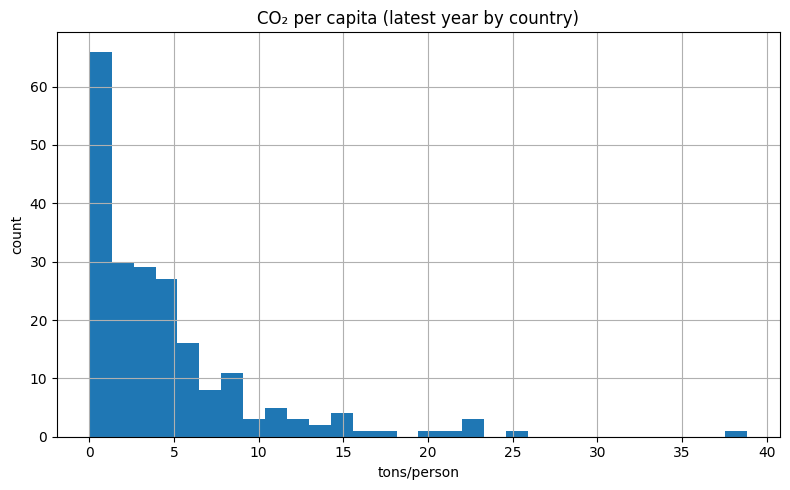

/tmp/ipython-input-2110190641.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=COUNTRIES, showfliers=False)


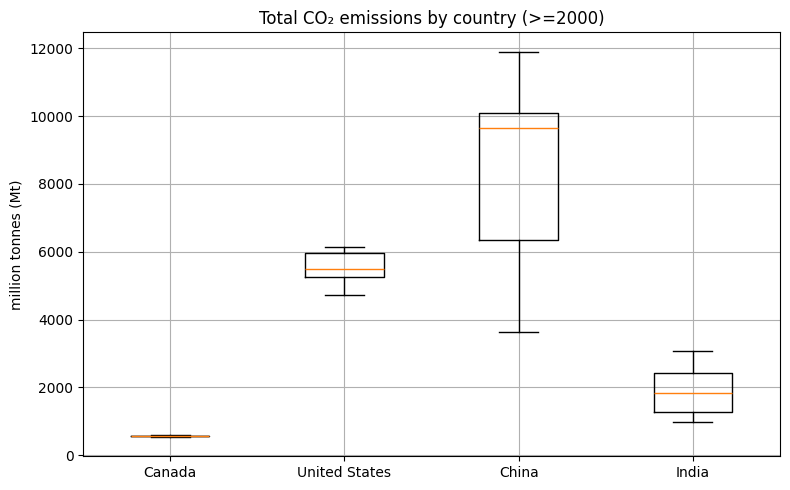

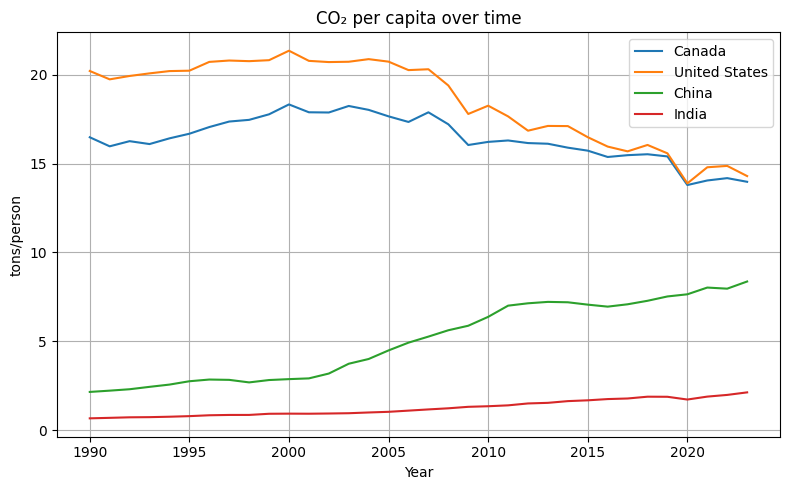

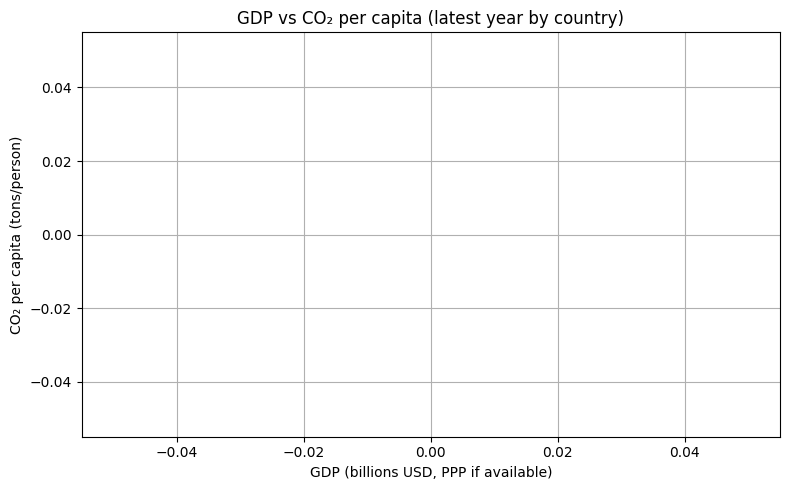

In [ ]:
# 4a) Histogram of CO2 per capita (latest year per country)
latest = df.sort_values('year').groupby('country').tail(1)
latest = latest.dropna(subset=['co2_per_capita'])

plt.figure()
plt.hist(latest['co2_per_capita'], bins=30)
plt.title('CO₂ per capita (latest year by country)')
plt.xlabel('tons/person')
plt.ylabel('count')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/ 'hist_co2_per_capita_latest.png', dpi=150)
plt.show()

# 4b) Boxplot of total CO2 by selected countries (recent decades)
subset = df[(df['country'].isin(COUNTRIES)) & (df['year']>=2000)].dropna(subset=['co2'])
data = [subset[subset['country']==c]['co2'].values for c in COUNTRIES]
plt.figure()
plt.boxplot(data, labels=COUNTRIES, showfliers=False)
plt.title('Total CO₂ emissions by country (>=2000)')
plt.ylabel('million tonnes (Mt)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/ 'box_co2_by_country.png', dpi=150)
plt.show()

# 4c) Time series: CO2 per capita for selected countries
plt.figure()
for c in COUNTRIES:
    s = dd[dd['country']==c].dropna(subset=['co2_per_capita'])
    plt.plot(s['year'], s['co2_per_capita'], label=c)
plt.title('CO₂ per capita over time')
plt.xlabel('Year'); plt.ylabel('tons/person')
plt.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/ 'ts_co2_per_capita.png', dpi=150)
plt.show()

# 4d) Scatter: GDP vs CO2 per capita (latest year)
scat = latest.dropna(subset=['gdp','co2_per_capita'])
plt.figure()
plt.scatter(scat['gdp']/1e9, scat['co2_per_capita'])
plt.title('GDP vs CO₂ per capita (latest year by country)')
plt.xlabel('GDP (billions USD, PPP if available)')
plt.ylabel('CO₂ per capita (tons/person)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/ 'scatter_gdp_vs_co2pc.png', dpi=150)
plt.show()


## 5) Correlation (numeric columns, latest year)
We'll compute a correlation matrix and visualize it with `imshow`.


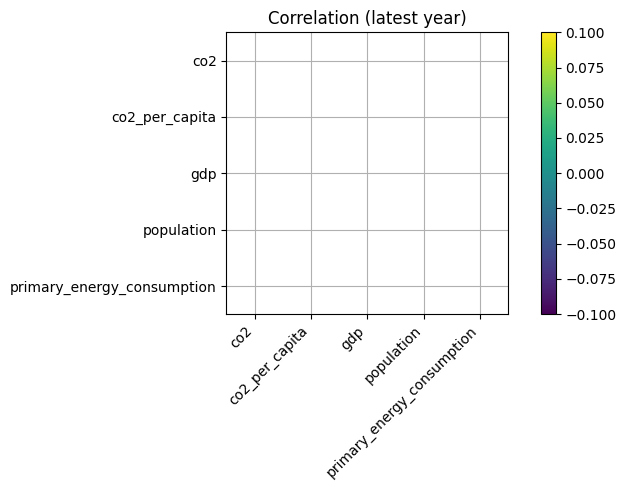

,co2,co2_per_capita,gdp,population,primary_energy_consumption
co2,NaN,NaN,NaN,NaN,NaN
co2_per_capita,NaN,NaN,NaN,NaN,NaN
gdp,NaN,NaN,NaN,NaN,NaN
population,NaN,NaN,NaN,NaN,NaN
primary_energy_consumption,NaN,NaN,NaN,NaN,NaN


In [ ]:
num_cols = ['co2','co2_per_capita','gdp','population','primary_energy_consumption']
corr_df = latest[num_cols].dropna()
corr = corr_df.corr(numeric_only=True)

plt.figure()
im = plt.imshow(corr.values, interpolation='nearest')
plt.title('Correlation (latest year)')
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(im)
plt.tight_layout(); plt.savefig(OUTPUT_DIR/ 'corr_heatmap.png', dpi=150)
plt.show()
corr

## 6) Hypothesis testing example
Test: **Is the mean CO₂ per capita for Canada in the 1990s different from the 2010s?**
- Null H₀: μ_1990s = μ_2010s
- Alt H₁: μ_1990s ≠ μ_2010s


In [ ]:
country = 'United States of Canada'
d_can = df[df['country']==country].dropna(subset=['co2_per_capita'])
co2_1990s = d_can[d_can['year'].between(1990,1999)]['co2_per_capita']
co2_2010s = d_can[d_can['year'].between(2010,2019)]['co2_per_capita']
print("n(1990s)=", len(co2_1990s), " n(2010s)=", len(co2_2010s))
t, p = stats.ttest_ind(co2_1990s, co2_2010s, equal_var=False, nan_policy='omit')
print({"t_stat": round(float(t),3), "p_value": round(float(p),5)})
print("Reject H0 at α=0.05? ", p < 0.05)

n(1990s)= 10  n(2010s)= 10
{'t_stat': 4.118, 'p_value': 0.00097}
Reject H0 at α=0.05?  True


## 7) Simple linear regression
Model: predict **CO₂ per capita** from **GDP** (latest year, cross‑section across countries).

{'coef_gdp': 1.0699665365890843e-12, 'intercept': 3.455388964937329, 'R2': 0.028, 'MAE': 3.732}


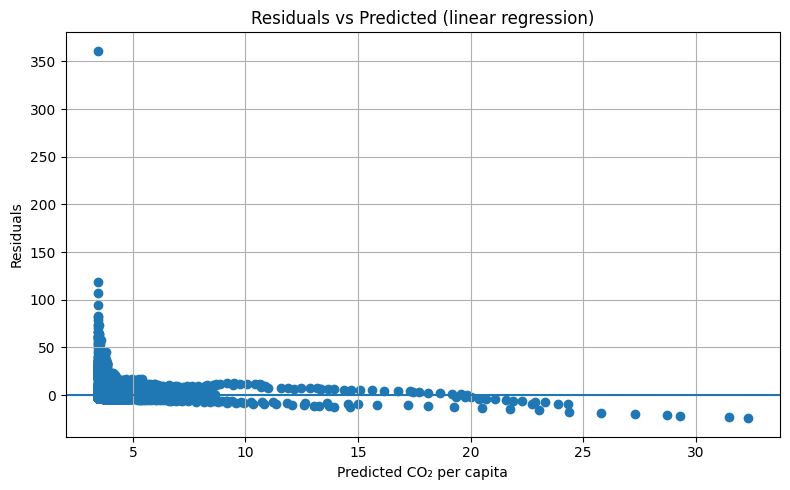

In [ ]:
cross = df.dropna(subset=['co2_per_capita','gdp']).copy()
X = (cross[['gdp']].values)
y = cross['co2_per_capita'].values
reg = LinearRegression().fit(X, y)
pred = reg.predict(X)
r2 = r2_score(y, pred)
mae = mean_absolute_error(y, pred)
print({"coef_gdp": float(reg.coef_[0]), "intercept": float(reg.intercept_), "R2": round(r2,3), "MAE": round(mae,3)})

# Residual plot
resid = y - pred
plt.figure()
plt.scatter(pred, resid)
plt.axhline(0)
plt.title('Residuals vs Predicted (linear regression)')
plt.xlabel('Predicted CO₂ per capita')
plt.ylabel('Residuals')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/ 'residuals_plot.png', dpi=150)
plt.show()

## 8) Save cleaned subsets
We'll save: latest snapshot, filtered country‑year subset, and summary stats.

In [ ]:
timestamp = pd.Timestamp.now().strftime('%Y-%m-%d_%H-%M-%S')
latest_out = OUTPUT_DIR / f'latest_snapshot_{timestamp}.csv'
dd_out = OUTPUT_DIR / f'selected_countries_{YEAR_MIN}_{YEAR_MAX}_{timestamp}.csv'
summary_out = OUTPUT_DIR / f'summary_stats_{timestamp}.csv'

latest.to_csv(latest_out, index=False)
dd.to_csv(dd_out, index=False)
df.describe(include='all').to_csv(summary_out)
print("Saved:", latest_out)
print("Saved:", dd_out)
print("Saved:", summary_out)

Saved: /content/drive/MyDrive/Colab_Projects/dataviz_stats_outputs/latest_snapshot_2025-10-09_23-46-33.csv
Saved: /content/drive/MyDrive/Colab_Projects/dataviz_stats_outputs/selected_countries_1990_2024_2025-10-09_23-46-33.csv
Saved: /content/drive/MyDrive/Colab_Projects/dataviz_stats_outputs/summary_stats_2025-10-09_23-46-33.csv


## 9) Extensions (try these!)
1. Replace `COUNTRIES` with your own list; redo charts.
2. Normalize emissions by GDP: `co2_intensity = co2 / gdp` and compare by country.
3. Build a multiple regression (e.g., predict `co2_per_capita` from `gdp`, `primary_energy_consumption`, `population`).
4. Add confidence intervals for a group mean using bootstrapping.
5. Export all figures into a single PDF report with `matplotlib.backends.backend_pdf.PdfPages`.


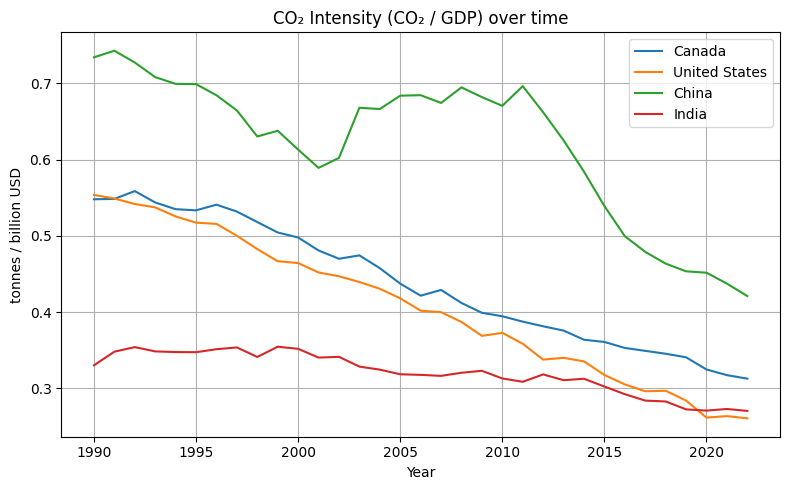

In [ ]:
# Extension 2: Normalize emissions by GDP and compare by country
dd['co2_intensity'] = dd['co2'] / dd['gdp'] * 1e9  # Normalize to tonnes per billion USD

plt.figure()
for c in COUNTRIES:
    s = dd[dd['country']==c].dropna(subset=['co2_intensity'])
    plt.plot(s['year'], s['co2_intensity'], label=c)
plt.title('CO₂ Intensity (CO₂ / GDP) over time')
plt.xlabel('Year')
plt.ylabel('tonnes / billion USD')
plt.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/ 'ts_co2_intensity.png', dpi=150)
plt.show()

In [ ]:
import statsmodels.api as sm
# Drop rows with NaN in 'gdp' or 'co2_per_capita'
dd_cleaned = dd.dropna(subset=['gdp', 'co2_per_capita']).copy()
X = sm.add_constant(dd_cleaned['gdp'])
model = sm.OLS(dd_cleaned['co2_per_capita'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         co2_per_capita   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.814
Date:                Thu, 09 Oct 2025   Prob (F-statistic):             0.0959
Time:                        23:50:36   Log-Likelihood:                -453.52
No. Observations:                 132   AIC:                             911.0
Df Residuals:                     130   BIC:                             916.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0041      1.033      8.718      0.0